In [1]:
pathtosrc="OneDrive\\Documents\\Kajol's Stuff\\University\\Masters Project\\HHGsimPL.jl-user\\HHGsimPL.jl-user\\src";

In [2]:
C:\\Users\\Katki\\OneDrive\\Documents\\Kajol's Stuff\\University\\Masters Project\\HHGsimPL.jl-user\\HHGsimPL.jl-user\\src

LoadError: ParseError:
[90m# Error @ [0;0m]8;;file://C:/Users/Katki/In[2]#1:3\[90mIn[2]:1:3[0;0m]8;;\
C:[48;2;120;70;70m\[0;0m\Users\\Katki\\OneDrive\\Documents\\Kajol's Stuff\\University\\Masters Project\\HHGsimPL.jl-user\\HHGsimPL.jl-user\\src
[90m# ╙ ── [0;0m[91mnot a unary operator[0;0m

In [3]:
include(pathtosrc*"/header/PLIntegration2D/PLIntegration2D.jl");
include(pathtosrc*"/header/PLIntegration2D/utils.jl");
include(pathtosrc*"/header/beams.jl");
include(pathtosrc*"/header/constants-units.jl");
include(pathtosrc*"/header/saddles.jl");
include(pathtosrc*"/header/Beams/BeamMono.jl")
include(pathtosrc*"/header/Beams/BeamTC.jl")
include(pathtosrc*"/header/Beams/BeamOTC.jl");
include(pathtosrc*"/header/equations.jl");
include(pathtosrc*"/header/harmonic-response.jl");

In [4]:
using Sobol
using NLsolve
using QuadGK
using LinearAlgebra
using Integrals
using FiniteDiff
using StaticArrays
using Contour
using Peaks
using FastGaussQuadrature
using GLMakie
using ColorSchemes

In [5]:
### Build my own beam ###

struct BeamK <: Beam
	E01::Float64
	E02::Float64
	omega1::Float64
	omega2::Float64
	epsilon1::Float64
	epsilon2::Float64
	phi::Float64
    theta::Float64

    function BeamK(;Intensity1::Real, Intensity2::Real,
		# omega
		lambda::Real, 
		r::Int64, s::Int64,
		epsilon1::Real, epsilon2::Real,
		phi::Real, theta::Real)
		
		E01 = sqrt(Intensity1/IAU)
		E02 = sqrt(Intensity2/IAU)
		omega = get_omega(lambda)
		omega1 = r*omega
		omega2 = s*omega
		epsilon1 = epsilon1
		epsilon2 = epsilon2
		
		new(E01,E02,omega1,omega2,epsilon1,epsilon2,phi,theta)
	end


	function BeamK(E01::Float64,
		E02::Float64,
		omega1::Float64,
		omega2::Float64,
		epsilon1::Float64,
		epsilon2::Float64,
		phi::Float64,
        theta::Float64)
		
		new(E01,E02,omega1,omega2,epsilon1,epsilon2,phi,theta)
	end
end

# outer constructor for no ellipticities
function Beam_Kajol(;Intensity1::Real, Intensity2::Real,
	lambda::Real,
	r::Int64,s::Int64,
	epsilon::Real,
	phi::Real,
    theta::Real)

	Beam_Kajol(Intensity1=Intensity1,Intensity2=Intensity2,
		lambda=lambda,
		r=r,s=s,
		epsilon1=0.,epsilon2=0.,
		phi=phi, theta=theta)
end

TCycle(b::BeamK) = 2*pi/b.omega1




TCycle (generic function with 4 methods)

In [6]:
## electric field

function electric_field(b::BeamK)
	phi = b.phi
	epsilon1 = b.epsilon1
	E01 = b.E01
	omega1 = b.omega1
	E02 = b.E02
	epsilon2 = b.epsilon2
	omega2 = b.omega2 # THIS SHALL NOT BE ZERO!!!! 
    theta = b.theta

    #rotmat1 = @SMatrix[1 0; 0 1]
	rotmat2 = @SMatrix[cos(theta) -sin(theta); sin(theta) cos(theta)]

	E1(t) = (E01/sqrt(1+epsilon1^2) .* [sin(omega1*t) ; -epsilon1*cos(omega1*t)] )
	E2(t) = rotmat2 * (E02/sqrt(1+epsilon2^2) .* [sin(omega2*t + phi); -epsilon2*cos(omega2*t + phi)] )

	E(t) = E1(t) + E2(t)

	return t -> E(t)
end
E(b::BeamK) = electric_field(b)

E (generic function with 4 methods)

In [7]:
## vector potential

function vector_potential(b::BeamK)
	phi = b.phi
	epsilon1 = b.epsilon1
	E01 = b.E01
	omega1 = b.omega1
	E02 = b.E02
	epsilon2 = b.epsilon2
	omega2 = b.omega2
    theta = b.theta

    rotmat2 = @SMatrix[cos(theta) -sin(theta); sin(theta) cos(theta)]

	rotmat1 = 1 #[0 -1; -1 0]

	A01 = E01/omega1/sqrt(1+epsilon1^2) 
	A02 = E02/omega2/sqrt(1+epsilon2^2)
	A1(t) = rotmat1 * (A01 .* [cos(omega1*t) ; epsilon1 * sin(omega1*t)])
	A2(t) = rotmat2 * (A02 .* [cos(omega2*t + phi); epsilon2 * sin(omega2*t + phi) ])

	A(t) = A1(t) .+ A2(t)

	return t -> A(t)
end 
A(b::BeamK) = vector_potential(b)

A (generic function with 4 methods)

In [8]:
## integrated vector potential

function integrated_vector_potential(b::BeamK)

	phi = b.phi
	epsilon1 = b.epsilon1
	E01 = b.E01
	omega1 = b.omega1
	E02 = b.E02
	epsilon2 = b.epsilon2
	omega2 = b.omega2 
    theta = b.theta

	rotmat1 = 1 #[0 -1; -1 0]
    rotmat2 = @SMatrix[cos(theta) -sin(theta); sin(theta) cos(theta)]

	A01 = E01/omega1/sqrt(1+epsilon1^2) 
	A02 = E02/omega2/sqrt(1+epsilon2^2)

	integral_over_A1(ti,tr) = rotmat1 * (A01 ./ omega1 .* [sin(omega1*tr) - sin(omega1*ti); epsilon1*(-cos(omega1*tr) + cos(omega1 * ti))])
	integral_over_A2(ti,tr) = rotmat2 * (A02 ./ omega2 .* [ sin(omega2*tr + phi) - sin(omega2*ti + phi) ; epsilon2*(-cos(omega2*tr + phi) + cos(omega2*ti + phi))])

	integral_over_A(ti,tr) = integral_over_A1(ti,tr) .+ integral_over_A2(ti,tr)

	return (ti,tr) -> integral_over_A(ti,tr)
end 

IA(b::BeamK) = integrated_vector_potential(b)

IA (generic function with 4 methods)

In [9]:
## intergrated squared vector potential -- this needs to be checked

function integrated_squared_vector_potential(b::BeamK)
    phi = b.phi
    epsilon1 = b.epsilon1
    E01 = b.E01
    omega1 = b.omega1
    E02 = b.E02
    epsilon2 = b.epsilon2
    omega2 = b.omega2 
    theta = b.theta

    A01 = E01/omega1/sqrt(1+epsilon1^2) 
    A02 = E02/omega2/sqrt(1+epsilon2^2)
    
    A01sq = A01^2
    A02sq = A02^2


    # term1(ti,tr) = 0.5 * A01^2 * (tr - ti)
    # term2(ti,tr) = 0.5 * A02^2 * (tr - ti)
    # term3(ti,tr) = A01^2 * (sin(2 * omega1 * tr) - sin(2 * omega1 * ti)) / (4 * omega1)
    # term4(ti,tr) = A02^2 * (sin(2 * omega2 * tr + 2 * phi) - sin(2 * omega2 * ti + 2 * phi)) / (4 * omega2)
    # term5(ti,tr) = 0.5 * A01 * A02 * (cos(theta) + sin(theta)) * sin((omega1 + omega2) * tr + phi) / (omega1 + omega2)
    # term6(ti,tr) = 0.5 * A01 * A02 * (cos(theta) + sin(theta)) * sin((omega1 - omega2) * tr - phi) / (omega1 - omega2)
    # term7(ti,tr) = -1 * 0.5 * A01 * A02 * (cos(theta) + sin(theta)) * sin((omega1 + omega2) * ti + phi) / (omega1 + omega2)
    # term8(ti,tr) = -1 * 0.5 * A01 * A02 * (cos(theta) + sin(theta)) * sin((omega1 - omega2) * ti - phi) / (omega1 - omega2)

    term1(ti,tr) = 0.5 * A01^2 * (tr - ti)
    term2(ti,tr) = 0.5 * A02^2 * (tr - ti)
    term3(ti,tr) = A01^2 * (sin(2 * omega1 * tr) - sin(2 * omega1 * ti)) / (4 * omega1)
    term4(ti,tr) = A02^2 * (sin(2 * omega2 * tr + 2 * phi) - sin(2 * omega2 * ti + 2 * phi)) / (4 * omega2)
    term5(ti,tr) = A01 * A02 * (cos(theta) + sin(theta)) * sin((omega1 + omega2) * tr + phi) / (omega1 + omega2)
    term6(ti,tr) =  A01 * A02 * (cos(theta) + sin(theta)) * sin((omega1 - omega2) * tr - phi) / (omega1 - omega2)
    term7(ti,tr) = -1 * A01 * A02 * (cos(theta) + sin(theta)) * sin((omega1 + omega2) * ti + phi) / (omega1 + omega2)
    term8(ti,tr) = -1 * A01 * A02 * (cos(theta) + sin(theta)) * sin((omega1 - omega2) * ti - phi) / (omega1 - omega2)



    (ti,tr) -> term1(ti,tr) + term2(ti,tr) + term3(ti,tr) + term4(ti,tr) + term5(ti,tr) + term6(ti,tr) + term7(ti,tr) + term8(ti,tr)
       
end
IAsq(b::BeamTC) = integrated_squared_vector_potential(b)

IAsq (generic function with 2 methods)

In [10]:
function S_v_analytic(b::BeamK, Ip::Float64, 
  ti::ComplexF64, tr::ComplexF64, 
  ps::Vector{ComplexF64} = p_stationary(b, ti, tr)
  )
    pssq = scalarproduct2(ps)
#     integral = integrate( sum((p+A(t)) .* (p+A(t)))  , t, ti, tr)
    integral = pssq*(tr-ti) + 2 * sum(ps .* IA(b)(ti,tr)) + IAsq(b)(ti,tr)
    
    0.5 * integral  + Ip * (tr - ti)
end

S_v_analytic (generic function with 7 methods)

In [11]:
function get_Up(b::BeamK)
	A01 = b.E01/b.omega1
	A02 = b.E02/b.omega2
	# println("Up = $(A01^2/4 + A02^2/4)")
	Up = A01^2/4 + A02^2/4
	return Up
end

get_Up (generic function with 4 methods)

In [12]:
const Ip = IpAU(15.6)

0.5732891361708695

In [13]:
q_values = range(10., stop = 40., step = 1.)

10.0:1.0:40.0

In [114]:
beam0=BeamK(Intensity1 = 1.3e14, Intensity2 = 1.3e12, lambda=800, r=1, s=2, phi=0, epsilon1 = 0., epsilon2 = 0., theta=0)

BeamK(0.0609449400220044, 0.00609449400220044, 0.056939529014612654, 0.11387905802922531, 0.0, 0.0, 0.0, 0.0)

In [115]:
fundamental_frequency(b::BeamK) = b.omega1

fundamental_frequency (generic function with 3 methods)

In [117]:
dict_dipoles, dict_saddles = let
    dict = Dict()
    dict_saddles = Dict()
    for q in q_values
    b = beam0

    timin, timax = (0., 1.) .* TCycle(b)
    ttmin, ttmax = (0.001, 1.) .* TCycle(b)
    
    ### define this 'phase function' as a function of two arguments (ionisation and recombiantion time)
    S_f(ti, tr) = -im*S(b, Ip, ti, tr, q)
    S_grad(ti, tr) = -1im .* [dS_dti(b,Ip,q,ti,tr); dS_dtr(b,Ip,q,ti,tr)]
    S_hessian(ti,tr) = my_hessian(b, Ip,q, ti, tr)
    function prefactor(ti,tr)
        ### eq. 5 from Emilio's thc paper
#         ti = tvec[1]; tr = tvec[2]
        ps = p_stationary(b, ti, tr)
        dip_r = dipole_SR_conj(ps .+ A(b)(tr), Ip)
        
        fontaine_SR_m0 = 1 / (kappa(Ip) * sqrt(2) * π)
        traveltime = tr - ti

        prefactor_const = (2*π/(im*traveltime))^(3/2) # spreading factor
        prefactor_const *= fontaine_SR_m0

        return prefactor_const * dip_r
    end
    
    ### iterating over fancy seeded grid, keeping only reasonable solutions, saving them as Sadddle object
    saddles = find_saddles_sobol(q; b = b, Ip = Ip,
        ti_cd = ComplexDomain(timin+0im, timax+30im),
        tr_cd = ComplexDomain(timin+ttmin-30im, timax+ttmax+30im), N= 500)

    int_spm = zeros(ComplexF64,2) # sum over gaussian contributions
    int_sdt = zeros(ComplexF64,2) # sum over integrating the attached thimbles
    
    ### determining whether they are relevant
    saddles_relevant = []
    for s in saddles
        # @show b
        # @show s.q
        if real(traveltime(s)) < TCycle(beam0)
            rel = check_contribution(b,Ip,s.q,s.ti, s.tr)
            if rel
                # println(s)
                int_spm_s = saddles_gaussian_contribution(S_f, S_hessian, s.ti, s.tr, prefactor = prefactor)
                int_spm .+= int_spm_s
                
                # int_sdt_s = integrate_SD_thimble(S_f, S_grad, S_hessian, s.ti, s.tr, prefactor=prefactor)
                # int_sdt .+= int_sdt_s
                push!(saddles_relevant, s)
                # @show int_spm_s
                # @show int_sdt_s
            end
            # println()
        end
    end
    #@show int_spm
    #@show int_sdt
    int_spm,int_sdt
    dict[q] = int_spm, int_sdt
    @show saddles
    dict_saddles[q] = saddles_relevant
    end
dict, dict_saddles
end;

saddles = Saddle[ti: 26.55 + 15.39im, tr: 138.17 + 1.58im, q10.0, ti: 26.55 + 15.39im, tr: 138.17 - 1.32im, q10.0, ti: 34.35 + 22.51im, tr: 64.33 - 9.8im, q10.0, ti: 34.35 + 22.51im, tr: 67.18 - 12.66im, q10.0, ti: 85.31 + 15.09im, tr: 195.09 - 1.48im, q10.0, ti: 85.31 + 15.09im, tr: 195.09 + 1.37im, q10.0, ti: 95.26 + 20.18im, tr: 117.15 - 8.71im, q10.0, ti: 95.26 + 20.18im, tr: 119.4 - 11.05im, q10.0]
saddles = Saddle[ti: 26.64 + 15.41im, tr: 133.04 + 0.13im, q11.0, ti: 26.65 + 15.41im, tr: 144.0 + 0.15im, q11.0, ti: 34.48 + 22.2im, tr: 71.83 - 6.85im, q11.0, ti: 34.62 + 22.34im, tr: 61.51 - 17.02im, q11.0, ti: 85.41 + 15.08im, tr: 189.82 - 0.06im, q11.0, ti: 85.41 + 15.08im, tr: 200.51 - 0.06im, q11.0, ti: 95.32 + 19.88im, tr: 123.5 - 6.22im, q11.0, ti: 95.44 + 20.0im, tr: 114.92 - 14.16im, q11.0]
saddles = Saddle[ti: 26.73 + 15.42im, tr: 130.84 + 0.13im, q12.0, ti: 26.76 + 15.43im, tr: 147.03 + 0.17im, q12.0, ti: 34.51 + 21.87im, tr: 74.76 - 5.46im, q12.0, ti: 34.91 + 22.25im, tr: 

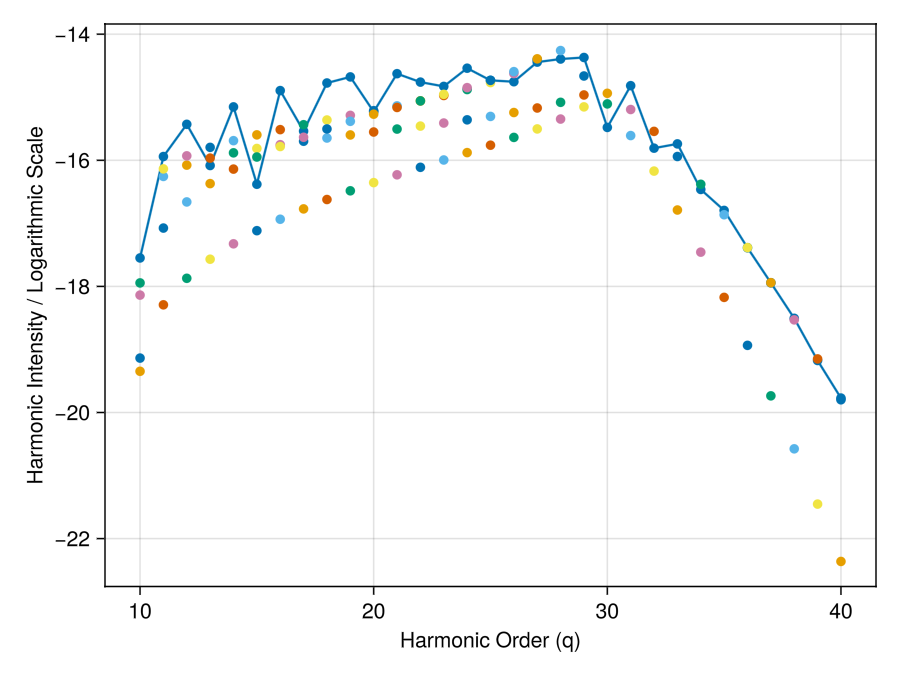

In [17]:
#plot Spectrum
let
    beam=beam0


    dict = dict_dipoles
    
    f = Figure()
    ax = Axis(f[1, 1],  
        xlabel = "Harmonic Order (q)",
        ylabel = "Harmonic Intensity / Logarithmic Scale"
        ) 
    
    scatterlines!(ax, q_values, [log10(harmonic_intensity(beam, dict[q][1], q)) for q in q_values])
    for q in q_values
        saddles = dict_saddles[q]
        for s in saddles
            scatter!(ax, [(q, log10(harmonic_intensity(beam,Ip, s)) )])
        end
    end

    #lines!(ax, q_values, [log10(harmonic_intensity(beam0, dict[q][2], q)) for q in q_values])

    f
end  